[T5]


[S3]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sp
from scipy.stats import norm, uniform

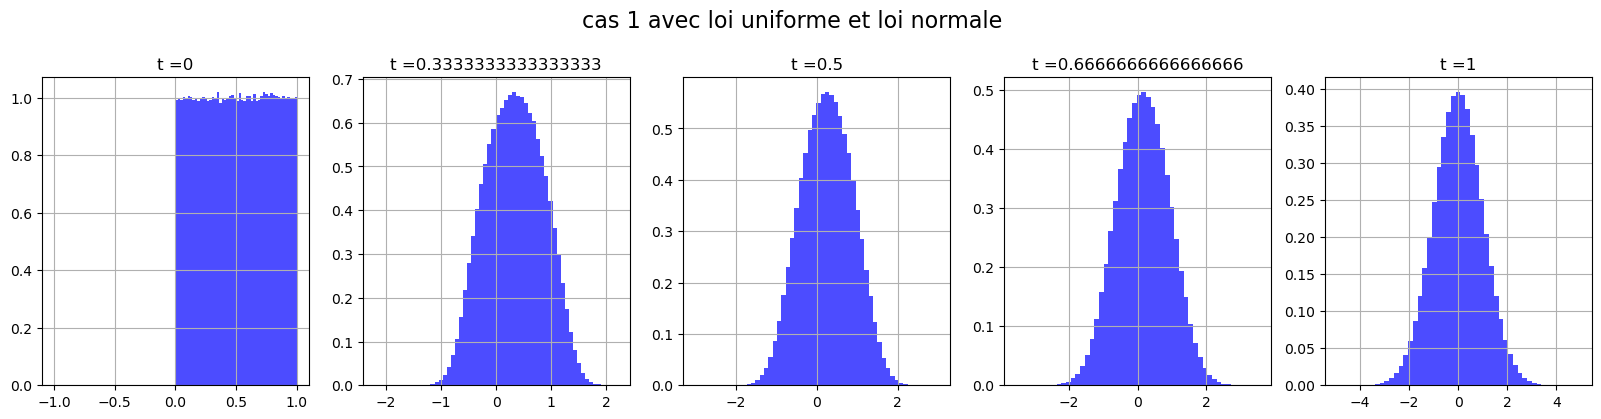

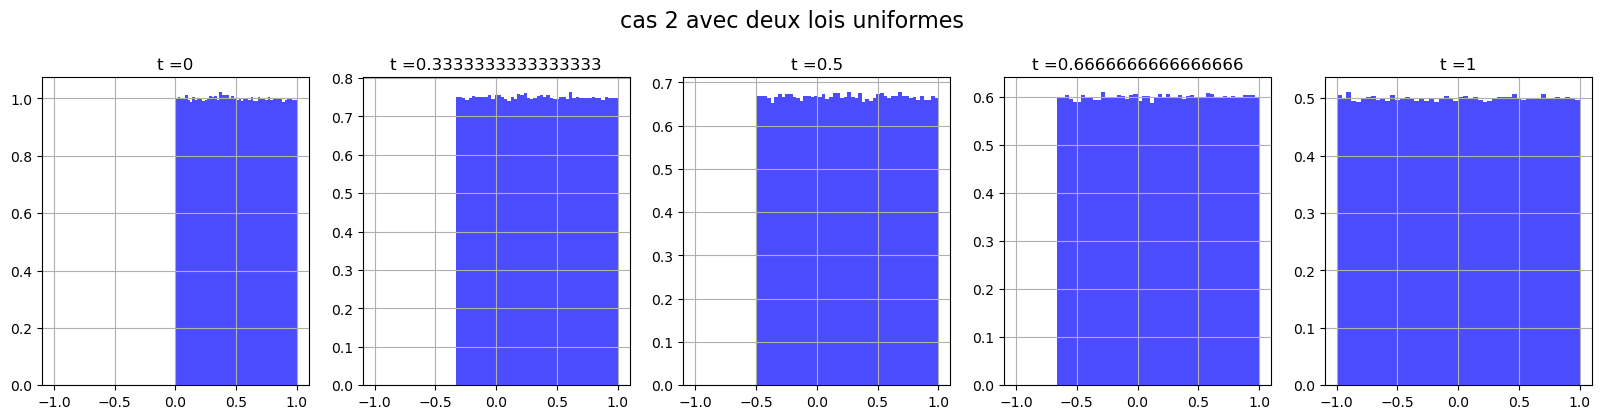

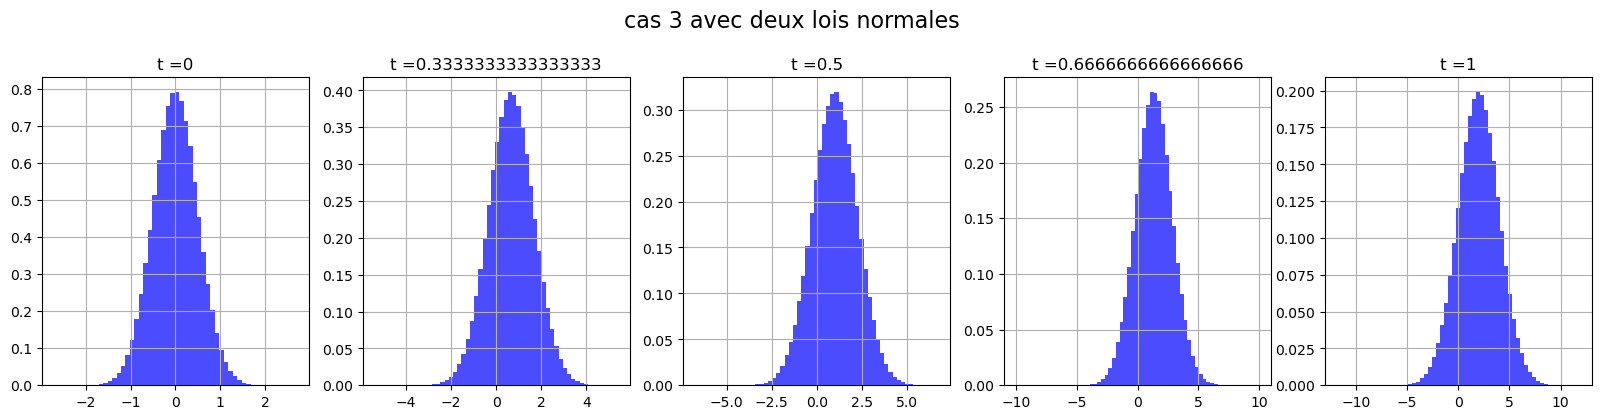

In [3]:
Lt=[0,1/3,0.5,2/3,1]

n_echantillon=1000000
 

def Zt(f0,f1,name):
    fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 4))
    fig.suptitle(name, fontsize=16, y=1.05)
    i=0
    for t in Lt:
        U = np.random.uniform(0, 1, n_echantillon)
        Z_t = (1 - t) * f0.ppf(U) + t * f1.ppf(U)
        max_abs = max(abs(np.min(Z_t)), abs(np.max(Z_t)))
        x_min, x_max = -max_abs * 1.1, max_abs * 1.1
        axes[i].hist(Z_t, bins=50, density=True, alpha=0.7, color='blue')
        axes[i].set_xlim(x_min, x_max)
        axes[i].set_title(f"t ="+str(t))
        axes[i].grid(True)
        i+=1

Zt(uniform, norm, "cas 1 avec loi uniforme et loi normale")

Zt(uniform, uniform(loc=-1, scale=2), "cas 2 avec deux lois uniformes")

Zt(norm(loc=0, scale=0.5), norm(loc=2, scale=2), "cas 3 avec deux lois normales")







[T5]

### 1. Famille des mesures de Dirac $\mathcal{M}_D = \{\delta_x, x \in \mathbb{R}\}$

- Fonction de répartition : Pour $\mu_0 = \delta_{x_0}$, on a :
  $$
  F_0(x') = \begin{cases}
  0 & \text{si } x' < x_0, \\
  1 & \text{si } x' \geq x_0.
  \end{cases}
  $$
  La fonction quantile inverse est donc :
  $$
  F_0^{-1}(u) = x_0 \quad \forall u \in [0,1].
  $$

- Interpolation : Si $\mu_0 = \delta_{x_0}$ et $\mu_1 = \delta_{x_1}$, alors :
  $$
  Z_t = (1-t)x_0 + t x_1.
  $$
  La loi de $Z_t$ est donc $\delta_{(1-t)x_0 + t x_1}$.

Conclusion :
La famille des mesures de Dirac est préservée :
$$
\nu_t = \delta_{(1-t)x_0 + t x_1} \in \mathcal{M}_D.
$$

---

### 2. Famille des mesures uniformes $\mathcal{M}_U = \{\mathcal{U}([a, b]), a < b\}$

- Fonction de répartition : Pour $\mu_0 = \mathcal{U}([a_0, b_0])$, on a :
  $$
  F_0(x') = \frac{x' - a_0}{b_0 - a_0} \quad \text{pour } x' \in [a_0, b_0].
  $$
  La fonction quantile inverse est :
  $$
  F_0^{-1}(u) = a_0 + u(b_0 - a_0) \quad \forall u \in [0,1].
  $$

- Interpolation : Si $\mu_0 = \mathcal{U}([a_0, b_0])$ et $\mu_1 = \mathcal{U}([a_1, b_1])$, alors :
  $$
  Z_t = (1-t)(a_0 + U(b_0 - a_0)) + t(a_1 + U(b_1 - a_1)).
  $$
  En simplifiant :
  $$
  Z_t = (1-t)a_0 + t a_1 + U \left[(1-t)(b_0 - a_0) + t(b_1 - a_1)\right].
  $$
  Comme $U \sim \mathcal{U}([0,1])$, on a :
  $$
  Z_t \sim \mathcal{U}\left([(1-t)a_0 + t a_1, (1-t)b_0 + t b_1]\right).
  $$

La famille des mesures uniformes est préservée :
$$
\nu_t = \mathcal{U}\left([(1-t)a_0 + t a_1, (1-t)b_0 + t b_1]\right) \in \mathcal{M}_U.
$$

### 3. Famille des mesures gaussiennes $\mathcal{M}_G = \{\mathcal{N}(m, \sigma^2), \sigma^2 > 0\}$

- Fonction de répartition : Pour $\mu_0 = \mathcal{N}(m_0, \sigma_0^2)$, on a :
  $$
  F_0(x') = \Phi\left(\frac{x' - m_0}{\sigma_0}\right),
  $$
  où $\Phi$ est la fonction de répartition de $\mathcal{N}(0,1)$. La fonction quantile inverse est :
  $$
  F_0^{-1}(u) = m_0 + \sigma_0 \Phi^{-1}(u) \quad \forall u \in [0,1].
  $$

- Interpolation : Si $\mu_0 = \mathcal{N}(m_0, \sigma_0^2)$ et $\mu_1 = \mathcal{N}(m_1, \sigma_1^2)$, alors :
  $$
  Z_t = (1-t)(m_0 + \sigma_0 \Phi^{-1}(U)) + t(m_1 + \sigma_1 \Phi^{-1}(U)).
  $$
  En simplifiant :
  $$
  Z_t = (1-t)m_0 + t m_1 + \left[(1-t)\sigma_0 + t \sigma_1\right] \Phi^{-1}(U).
  $$
  Comme $\Phi^{-1}(U) \sim \mathcal{N}(0,1)$, on a :
  $$
  Z_t \sim \mathcal{N}\left((1-t)m_0 + t m_1, \left[(1-t)\sigma_0 + t \sigma_1\right]^2\right).
  $$

La famille des mesures gaussiennes est préservée :
$$
\nu_t = \mathcal{N}\left((1-t)m_0 + t m_1, \left[(1-t)\sigma_0 + t \sigma_1\right]^2\right) \in \mathcal{M}_G.
$$


### Conclusion 
L'opération d'interpolation $Z_t$ préserve les trois familles :
- Dirac : $\nu_t = \delta_{(1-t)x_0 + t x_1}$,
- Uniforme : $\nu_t = \mathcal{U}\left([(1-t)a_0 + t a_1, (1-t)b_0 + t b_1]\right)$,
- Gaussienne : $\nu_t = \mathcal{N}\left((1-t)m_0 + t m_1, \left[(1-t)\sigma_0 + t \sigma_1\right]^2\right)$.